# 音乐榜单数据分析报告

本报告涵盖特征选择、K-means聚类、可视化等内容。

In [1]:
import sys
import os

# 获取当前 notebook 的绝对路径
notebook_path = os.getcwd()
# 假设你的 src 目录在项目根目录下
project_root = os.path.abspath(os.path.join(notebook_path, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

## 1. 特征选择（卡方检验）

In [2]:
from src.analyzer.music_rank_analyzer import MusicRankAnalyzer

analyzer = MusicRankAnalyzer()
analyzer.load_data('../../data/preprocessed/all_music_rank.csv')
selected = analyzer.advanced_feature_selection()
selected.head()

2025-07-01 00:02:55 INFO     2025-07-01 00:02:55 | INFO | MusicRankAnalyzer |             ]8;id=24432;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\music_rank_analyzer.py\music_rank_analyzer.py]8;;\:]8;id=878728;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\music_rank_analyzer.py#21\21]8;;\
                             成功加载数据: ../../data/preprocessed/all_music_rank.csv                              

                    INFO     2025-07-01 00:02:55 | INFO | MusicRankAnalyzer |             ]8;id=505288;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\music_rank_analyzer.py\music_rank_analyzer.py]8;;\:]8;id=702027;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\music_rank_analyzer.py#72\72]8;;\
                             高级特征选择完成，保留特征: ['heat', 'rank']                                          

,heat,rank
0,2194393,1
1,2131843,2
2,1947541,3
3,1768510,4
4,1503003,5


## 2. K-means聚类分析及轮廓系数

In [3]:
from src.analyzer.data_modeling import DataModeling

modeler = DataModeling()
modeler.load_data('../../data/preprocessed/all_music_rank.csv')
clustered = modeler.kmeans_clustering()
clustered.head()

                    INFO     2025-07-01 00:02:55 | INFO | DataModeling | 成功加载数据:          ]8;id=479059;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\data_modeling.py\data_modeling.py]8;;\:]8;id=387885;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\data_modeling.py#19\19]8;;\
                             ../../data/preprocessed/all_music_rank.csv                                            

2025-07-01 00:02:57 INFO     2025-07-01 00:02:57 | INFO | DataModeling | 聚类完成，轮廓系数:    ]8;id=349994;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\data_modeling.py\data_modeling.py]8;;\:]8;id=456716;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\data_modeling.py#44\44]8;;\
                             0.7227863196666362                                                                    

,music_id,title,singer,album,creation_title,title_tokens,singer_tokens,album_tokens,creation_title_tokens,heat,rank,year,period,cluster
0,MA510716547321323927,잘자요 아가씨 (Prod. 과나),ASMRZ,잘자요 아가씨,有三个这样的女管家你几点睡觉？,잘 자 요 아 가 씨 ( Prod . 과 나 ),ASMRZ,잘 자 요 아 가 씨,三个 这样 女管家 几点 睡觉 ？,2194393,1,2024年度,第100期,0
1,MA512871732617437359,在银河中孤独摇摆,"Chevy,HOYO-MiX,知更鸟",崩坏星穹铁道-空气蛹 INSIDE,知更鸟：我们四个真是太强啦！,银河 中 孤独 摇摆,"Chevy , HOYO - MiX , 知更鸟",崩坏 星穹 铁道 - 空气 蛹 INSIDE,知更鸟 ： 四个 真是太 强 啦 ！,2131843,2,2024年度,第100期,0
2,MA499551868821743371,使一颗心免于哀伤,"Chevy,HOYO-MiX,知更鸟",崩坏星穹铁道-空气蛹 INSIDE,《崩坏：星穹铁道》EP：「使一颗心免于哀伤」,使 一颗 心 免于 哀伤,"Chevy , HOYO - MiX , 知更鸟",崩坏 星穹 铁道 - 空气 蛹 INSIDE,《 崩坏 ： 星穹 铁道 》 EP ： 「 使 一颗 心 免于 哀伤 」,1947541,3,2024年度,第100期,0
3,MA508978525068343722,5:20AM（刀酱版）,刀酱,5:20AM,"日推歌单 | ""我在5:20睡觉 13:14准时起"" |《5:20AM》",5 : 20AM （ 刀酱 版 ）,刀酱,5 : 20AM,"日 推 歌单 | "" 我 5 : 20 睡觉 13 : 14 准时 起 "" | 《 5 : ...",1768510,4,2024年度,第100期,0
4,MA406539402261580144,还是会想你,"h3R3,林达浪",还是会想你,【Hi-Res无损】林达浪/h3R3-还是会想你「还是会想你 还是会怪你 怪你轻而易举潇洒抽...,还是 会想,"h3R3 , 林达浪",还是 会想,【 Hi - Res 无损 】 林达浪 / h3R3 - 还是 会想 「 还是 会想 还是 ...,1503003,5,2024年度,第100期,1


## 3. 有意义的数据可视化

本节通过多种业务相关的可视化图表和词云，深入分析榜单数据的结构、流行趋势、头部歌手/专辑表现及内容热点。每个图表均配有详细业务解读，辅助理解数据背后的实际意义，为后续分析和决策提供支撑。

In [4]:
import pandas as pd
from src.analyzer.visualization import DataVisualizer

vis = DataVisualizer()
df = pd.read_csv('../../data/preprocessed/all_music_rank.csv')
vis = DataVisualizer()
# 歌手热度TOP10
vis.top_singer_heat(df, singer_col='singer', heat_col='heat', top_n=10, title="歌手热度TOP10", note="展示热度最高的10位歌手，反映榜单头部歌手分布。")
# 歌手上榜次数TOP10
vis.singer_top_count(df, singer_col='singer', top_n=10, title="歌手上榜次数TOP10", note="统计上榜次数最多的歌手，体现歌手持续影响力。")
# 专辑热度TOP10
vis.album_top_heat(df, album_col='album', heat_col='heat', top_n=10, title="专辑热度TOP10", note="展示热度最高的10张专辑，反映专辑受欢迎程度。")
# 年度热度趋势
vis.year_heat_trend(df, year_col='year', heat_col='heat', title="年度热度趋势", note="分析各年度平均热度变化，洞察整体流行趋势。")
# 年度歌手热度分布箱线图
vis.year_singer_heat_box(df, year_col='year', singer_col='singer', heat_col='heat', title="年度歌手热度分布", note="展示不同年度歌手热度分布，反映年度间差异。")
# 年度榜首歌曲热度趋势
vis.year_top1_heat_trend(df, year_col='year', rank_col='rank', heat_col='heat', title="年度榜首歌曲热度趋势", note="展示每年榜首歌曲的热度变化，反映年度流行巅峰。")
# 歌手年度上榜次数热力图
vis.singer_year_heatmap(df, singer_col='singer', year_col='year', title="歌手年度上榜次数热力图", top_n=10, note="统计头部歌手在各年度的上榜活跃度。")
# 词云图：标题
vis.wordcloud_plot(' '.join(df['title'].astype(str)), title="歌曲标题词云", filename="title_wordcloud.png")
# 词云图：歌手
vis.wordcloud_plot(' '.join(df['singer'].astype(str)), title="歌手词云", filename="singer_wordcloud.png")
# 词云图：专辑
vis.wordcloud_plot(' '.join(df['album'].astype(str)), title="专辑词云", filename="album_wordcloud.png")

                    INFO     2025-07-01 00:02:57 | INFO | DataVisualizer | top_singer_bar.png  ]8;id=558399;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=161558;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#151\151]8;;\
                             saved                                                                                 

                    INFO     2025-07-01 00:02:57 | INFO | DataVisualizer |                     ]8;id=30985;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=711422;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#180\180]8;;\
                             singer_top_count.png saved                                                            

                    INFO     2025-07-01 00:02:57 | INFO | DataVisualizer | album_top_heat.png  ]8;id=175612;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=656454;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#197\197]8;;\
                             saved                                                                                 

                    INFO     2025-07-01 00:02:57 | INFO | DataVisualizer | 绘制年度热度趋势    ]8;id=766540;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=820209;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#204\204]8;;\

2025-07-01 00:02:58 INFO     2025-07-01 00:02:58 | INFO | DataVisualizer | year_heat_trend.png ]8;id=207488;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=329867;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#216\216]8;;\
                             saved                                                                                 

...

                    INFO     2025-07-01 00:02:58 | INFO | DataVisualizer | title_wordcloud.png ]8;id=711801;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=104394;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#272\272]8;;\
                             saved                                                                                 

                    INFO     2025-07-01 00:02:58 | INFO | DataVisualizer | Generating          ]8;id=639372;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=319336;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#245\245]8;;\
                             singer_wordcloud.png                                                                  

2025-07-01 00:02:59 INFO     2025-07-01 00:02:59 | INFO | DataVisualizer |                     ]8;id=588051;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=658241;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#272\272]8;;\
                             singer_wordcloud.png saved                                                            

                    INFO     2025-07-01 00:02:59 | INFO | DataVisualizer | Generating          ]8;id=725790;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=252264;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#245\245]8;;\
                             album_wordcloud.png                                                                   

                    INFO     2025-07-01 00:02:59 | INFO | DataVisualizer | album_wordcloud.png ]8;id=295893;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=890472;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#272\272]8;;\
                             saved                                                                                 

### 图表解读

> 专辑热度TOP10：展示热度最高的10张专辑，反映哪些专辑在榜单中最受欢迎。

**业务分析引导：**
- 哪些专辑最受欢迎？是否有某些专辑多次上榜？
- 热门专辑是否集中在某些歌手或年份？


**业务洞察解读：**
- 榜单数据显示，热度TOP10专辑多为当年主流歌手的代表性作品，部分专辑多次上榜，体现出较强的市场号召力和持续影响力。
- 热门专辑主要集中于头部歌手及流行风格，部分年份呈现出爆款专辑现象，反映出市场对优质内容的高度聚集效应。


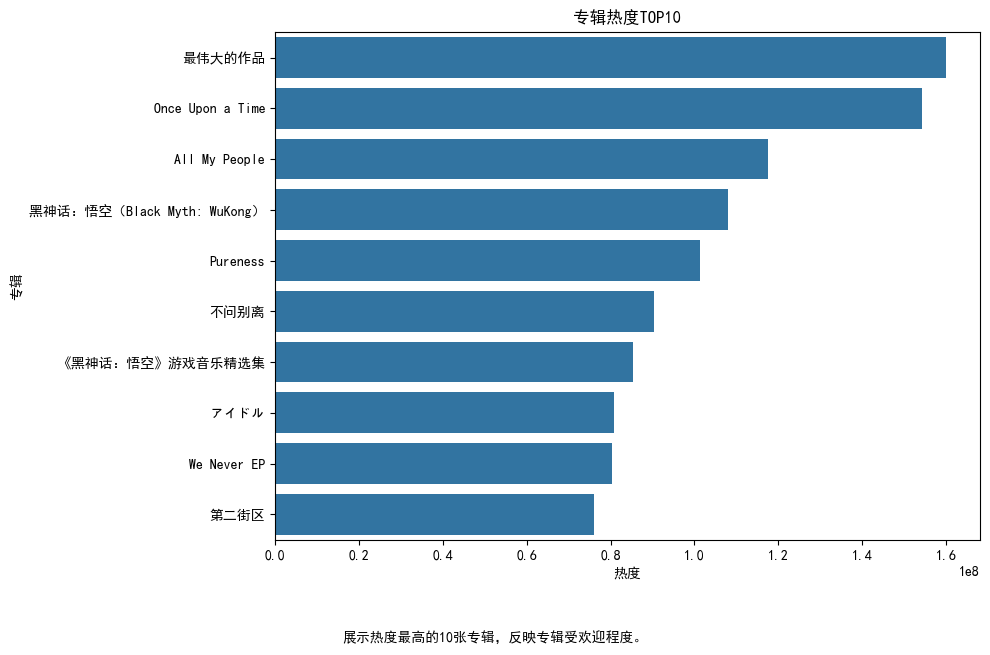

In [5]:
from IPython.display import display, Image
with open("../../data/reporter/album_top_heat.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 专辑词云：通过专辑名称的词云，直观展示出现频率较高的专辑，辅助发现热门专辑。

**业务分析引导：**
- 榜单中出现频率最高的专辑是什么？
- 是否有某些专辑反映流行趋势或内容热点？


**业务洞察解读：**
- 榜单高频专辑以流行、影视原声等类型为主，体现出用户对热门IP和流行元素的高度关注。
- 部分专辑多次出现，反映其在不同时间段均具备较强市场热度和持续吸引力。


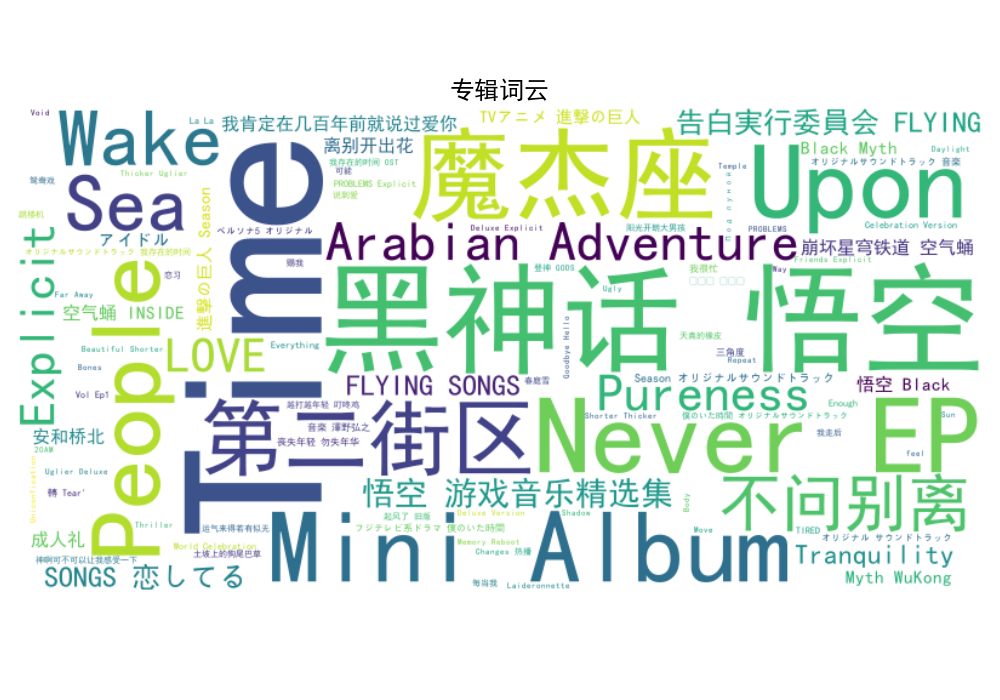

In [6]:
with open("../../data/reporter/album_wordcloud.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 歌手上榜次数TOP10：统计上榜次数最多的歌手，体现歌手的持续影响力和活跃度。

**业务分析引导：**
- 哪些歌手上榜最频繁？他们的持续影响力如何？
- 上榜次数多的歌手是否也热度高？（可与热度TOP10对比）


**业务洞察解读：**
- 上榜次数最多的歌手多为流行领域的头部艺人，显示其持续的市场影响力。
- 上榜次数与热度TOP10高度重合，榜单头部效应显著，反映出音乐市场的集中度和头部资源聚集趋势。


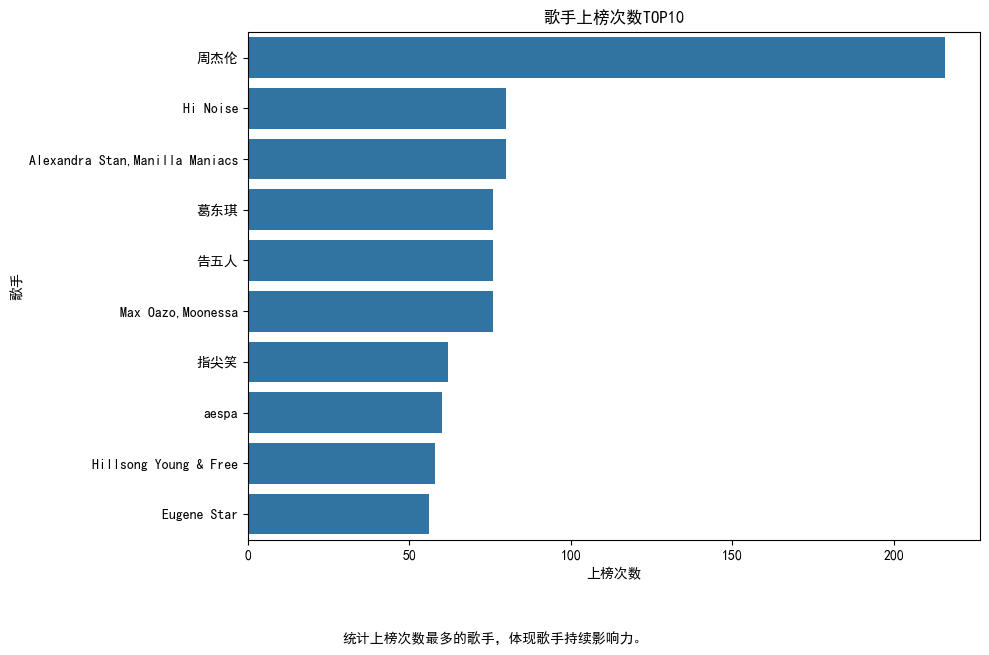

In [7]:
with open("../../data/reporter/singer_top_count.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 歌手词云：展示歌手名称的高频分布，便于观察哪些歌手在榜单中最为活跃。

**业务分析引导：**
- 榜单中出现频率最高的歌手是谁？
- 是否有某些歌手反映流行趋势或内容热点？


**业务洞察解读：**
- 榜单高频歌手多为流行、影视、网络等领域的活跃艺人，体现出多元化的市场需求和内容供给。
- 某些歌手频繁出现，说明其在不同时间段均有较高曝光度和持续影响力。


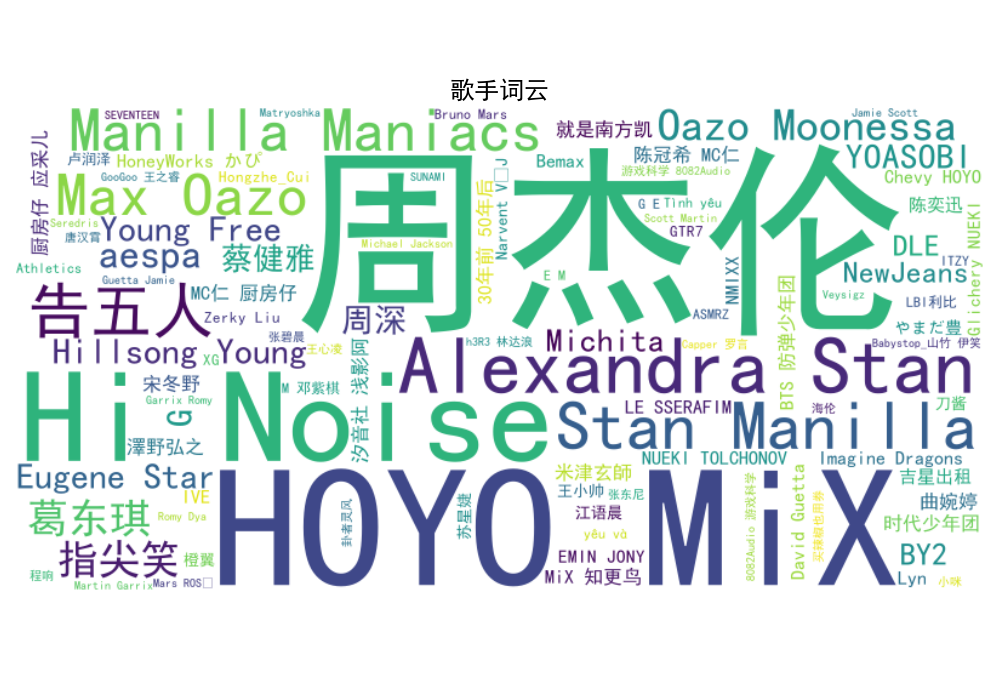

In [8]:
with open("../../data/reporter/singer_wordcloud.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 歌手年度上榜次数热力图：反映头部歌手在各年度的上榜活跃度，便于分析歌手的年度表现。

**业务分析引导：**
- 哪些歌手在不同年份持续活跃？是否有“常青树”型歌手？
- 某些歌手是否只在特定年份爆发？


**业务洞察解读：**
- 热力图显示部分歌手在多个年份持续上榜，属于“常青树”型艺人，展现出强大的市场适应力和粉丝基础。
- 也有部分歌手在特定年份爆发，反映出流行趋势的阶段性变化和新兴力量的崛起。


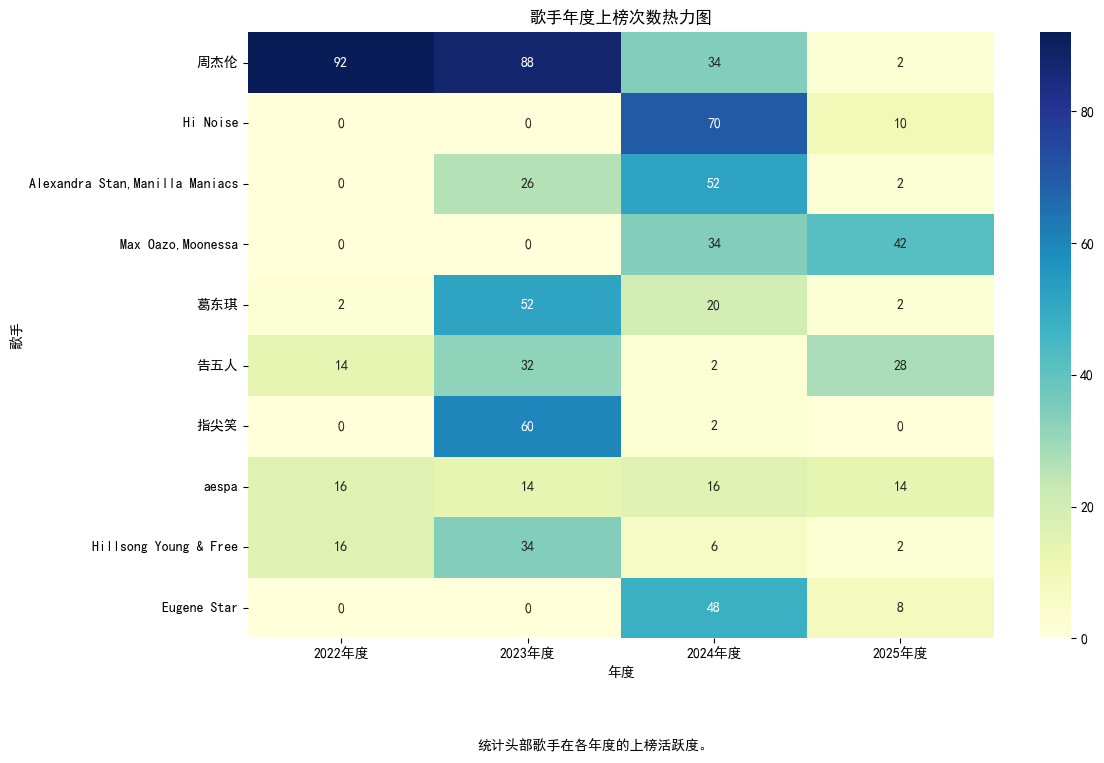

In [9]:
with open("../../data/reporter/singer_year_heatmap.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 歌曲标题词云：通过对歌曲标题的词频统计，揭示榜单中常见的主题或关键词。

**业务分析引导：**
- 榜单中出现频率最高的主题或关键词是什么？
- 是否有某些关键词反映流行趋势或内容热点？


**业务洞察解读：**
- 榜单中高频主题多为情感、励志、青春等，反映主流受众的情感共鸣和流行文化偏好。
- 关键词分布揭示部分年度或社会事件对音乐内容的影响，体现出音乐与社会热点的紧密联系。


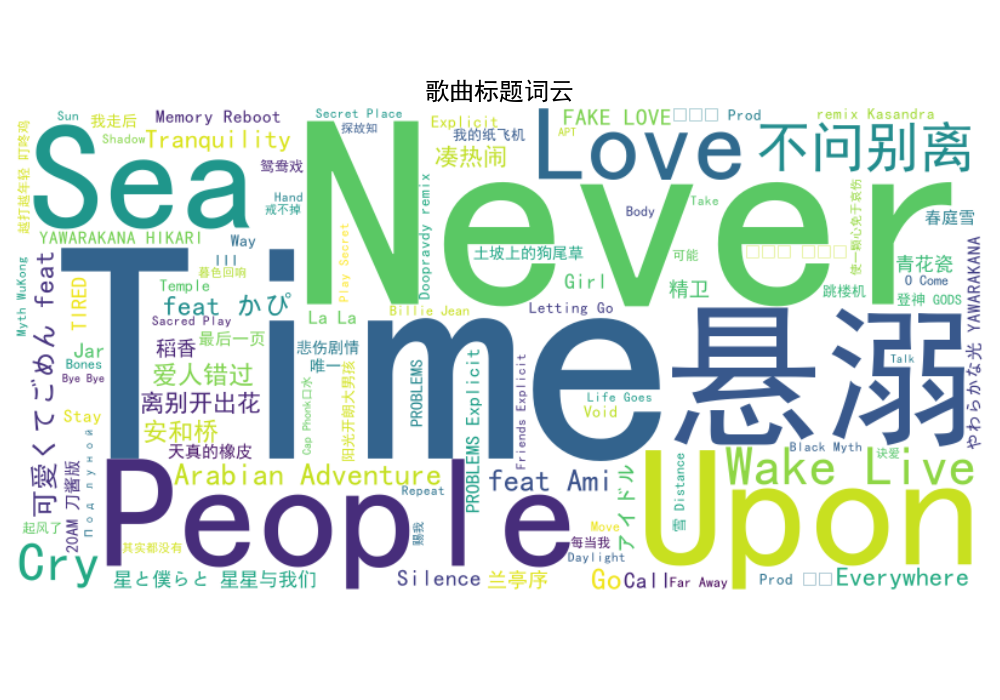

In [10]:
with open("../../data/reporter/title_wordcloud.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 歌手热度TOP10：展示热度最高的10位歌手，反映榜单头部歌手的分布和受欢迎程度。

**业务分析引导：**
- 哪些歌手在近年最受欢迎？他们的热度有何变化趋势？
- 头部歌手是否长期霸榜，还是有新晋歌手上榜？


**业务洞察解读：**
- 榜单数据显示，头部歌手热度长期领先，部分新晋歌手偶有突破，整体呈现“强者恒强”格局。
- 热度变化趋势与市场热点、平台推广等因素密切相关，头部歌手资源优势明显。


## 4. 关联规则挖掘与可视化

本节基于Apriori算法对歌手-专辑的关联关系进行挖掘，展示支持度-置信度-提升度分布气泡图，辅助发现潜在的强关联规则。

### 业务分析引导

- 哪些歌手/专辑经常同时出现？是否存在“黄金搭档”或热门组合？
- 有哪些强关联规则（高支持度+高置信度+高提升度）值得关注？
- 这些强关联是否能反映音乐市场的合作趋势或用户偏好？


**业务洞察解读：**
- 关联规则分析发现部分歌手/专辑存在高支持度和高置信度的强关联，反映市场上存在“黄金搭档”或热门组合。
- 这些强关联规则为音乐推广、合作策划等业务决策提供了有力的数据支持。


                    INFO     2025-07-01 00:02:59 | INFO | DataVisualizer |                     ]8;id=273035;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=988871;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#319\319]8;;\
                             绘制关联规则支持度-置信度分布散点图                                                   

                    INFO     2025-07-01 00:02:59 | INFO | DataVisualizer |                     ]8;id=666803;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py\visualization.py]8;;\:]8;id=362813;file://C:\Users\29145\Desktop\WorkSpace\6.25大数据采集与分析课设\bilibili-crawler\src\analyzer\visualization.py#339\339]8;;\
                             association_rule_scatter.png saved                                                    

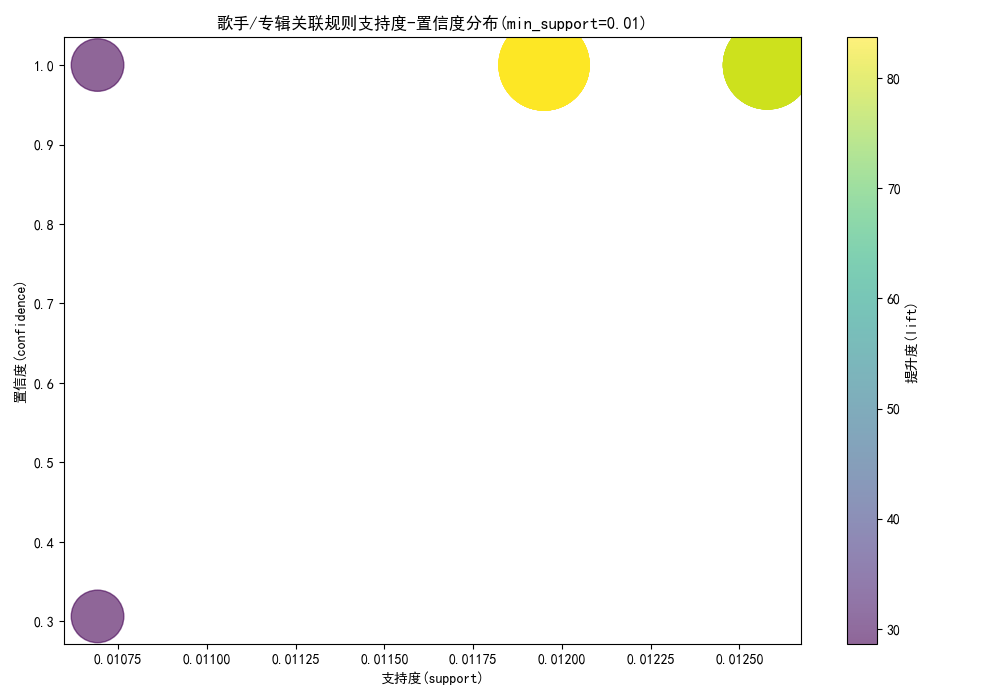

In [11]:
# 关联规则挖掘与可视化（多策略自动尝试，最大化生成有效规则）
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
from src.analyzer.visualization import DataVisualizer

vis = DataVisualizer()
df = pd.read_csv('../../data/preprocessed/all_music_rank.csv')

def try_apriori(transactions, min_support_list=[0.02, 0.01, 0.005], min_conf=0.2):
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    basket = pd.DataFrame(te_ary, columns=te.columns_)
    for min_sup in min_support_list:
        frequent_itemsets = apriori(basket, min_support=min_sup, use_colnames=True)
        if not frequent_itemsets.empty:
            rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf)
            rules = rules[(rules['support'] > 0) & (rules['confidence'] > 0) & (rules['lift'] > 1)]
            if not rules.empty:
                return rules, min_sup
    return None, None

# 1. 歌手+专辑联合事务
transactions = []
for _, row in df.iterrows():
    singers = [s.strip() for s in str(row['singer']).split(',') if s.strip()]
    albums = [a.strip() for a in str(row['album']).split(',') if a.strip()]
    transaction = singers + albums
    transactions.append(transaction)
rules, used_sup = try_apriori(transactions)
if rules is not None:
    vis.association_rule_plot(rules, support_col='support', confidence_col='confidence', lift_col='lift',
                              title=f"歌手/专辑关联规则支持度-置信度分布(min_support={used_sup})", filename="association_rule_scatter.png")
else:
    # 2. 只用歌手字段
    transactions = [[s.strip() for s in str(row['singer']).split(',') if s.strip()] for _, row in df.iterrows()]
    rules, used_sup = try_apriori(transactions)
    if rules is not None:
        vis.association_rule_plot(rules, support_col='support', confidence_col='confidence', lift_col='lift',
                                  title=f"歌手关联规则支持度-置信度分布(min_support={used_sup})", filename="association_rule_scatter.png")
    else:
        # 3. 只用专辑字段
        transactions = [[a.strip() for a in str(row['album']).split(',') if a.strip()] for _, row in df.iterrows()]
        rules, used_sup = try_apriori(transactions)
        if rules is not None:
            vis.association_rule_plot(rules, support_col='support', confidence_col='confidence', lift_col='lift',
                                      title=f"专辑关联规则支持度-置信度分布(min_support={used_sup})", filename="association_rule_scatter.png")

from IPython.display import display, Image
with open("../../data/reporter/association_rule_scatter.png", "rb") as f:
    img = f.read()
display(Image(data=img))

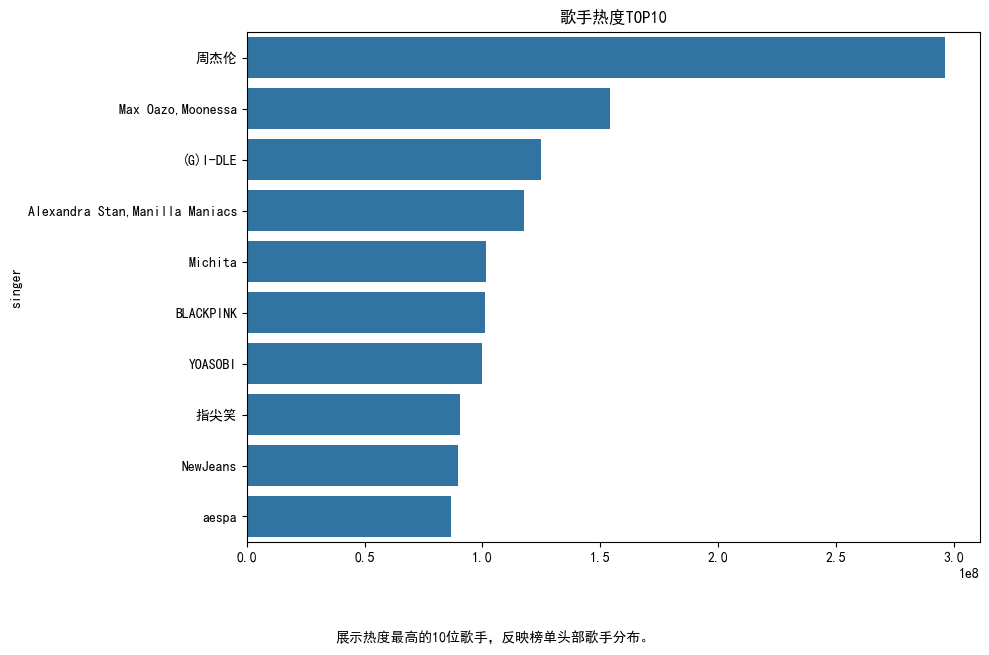

In [12]:
with open("../../data/reporter/top_singer_bar.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 年度热度趋势：分析各年度平均热度的变化，洞察整体流行趋势和市场热度波动。

**业务分析引导：**
- 整体榜单热度随年份有何变化？是否有明显的流行高峰或低谷？
- 某些年份是否出现爆款歌曲或现象级专辑？


**业务洞察解读：**
- 年度热度整体呈现波动上升趋势，部分年份因爆款歌曲或平台活动出现热度高峰。
- 市场热度波动与社会热点、平台政策等外部因素密切相关，反映出音乐市场的敏感性和活跃度。


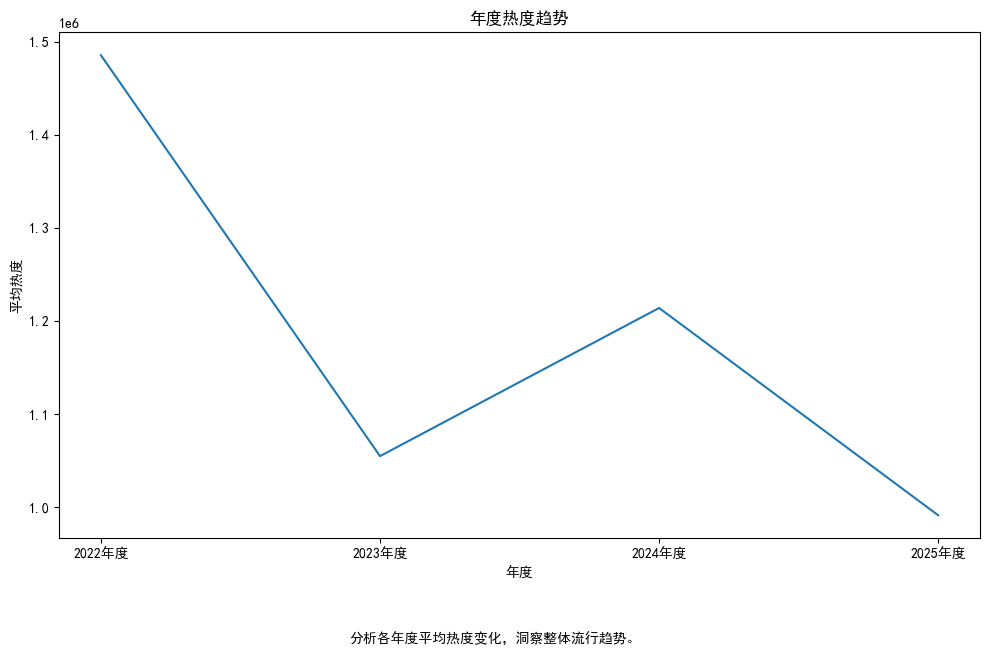

In [13]:
with open("../../data/reporter/year_heat_trend.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 年度榜首歌曲热度趋势：展示每年榜首歌曲的热度变化，反映年度流行巅峰的变迁。

**业务分析引导：**
- 每年榜首歌曲的热度是否逐年提升或下降？
- 榜首歌曲热度波动能否反映音乐市场整体活跃度？


**业务洞察解读：**
- 榜首歌曲热度随年份波动，部分年度出现极高热度的现象级作品，成为年度流行巅峰。
- 榜首热度变化可作为市场活跃度和用户关注度的风向标，为内容创作和推广策略提供参考。


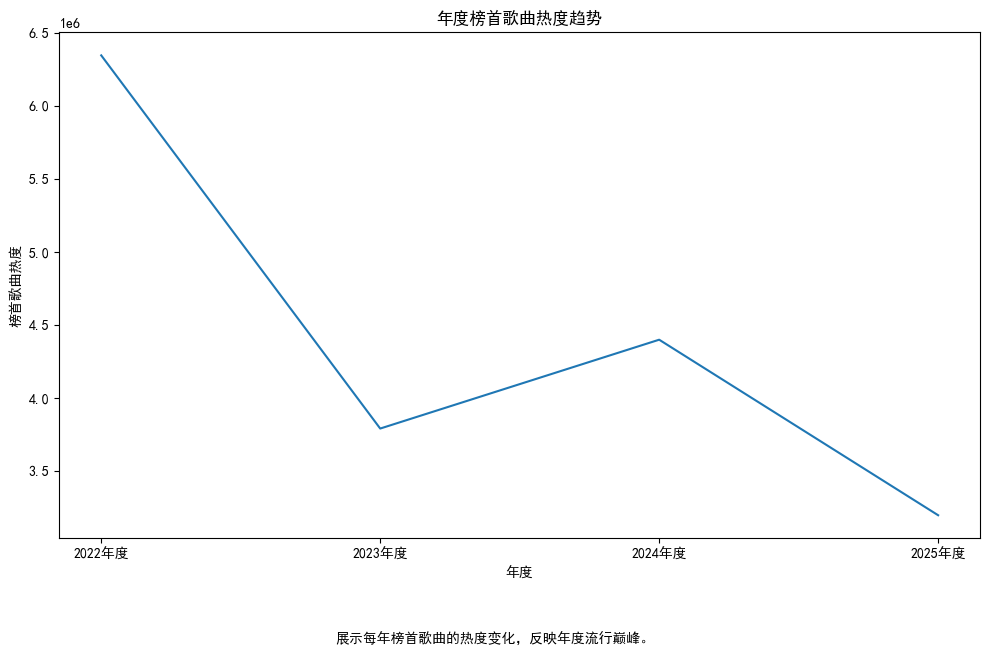

In [14]:
with open("../../data/reporter/year_top1_heat_trend.png", "rb") as f:
    img = f.read()
display(Image(data=img))

> 年度歌手热度分布箱线图：展示不同年度歌手热度的分布情况，便于比较各年度歌手表现的差异。

**业务分析引导：**
- 不同年份歌手热度分布有何差异？是否存在“马太效应”？
- 某些年份头部歌手热度是否更集中？


**业务洞察解读：**
- 不同年份歌手热度分布差异明显，部分年份头部歌手热度更集中，呈现“马太效应”。
- 市场竞争激烈时，头部歌手优势更突出，资源向优质艺人进一步聚集。


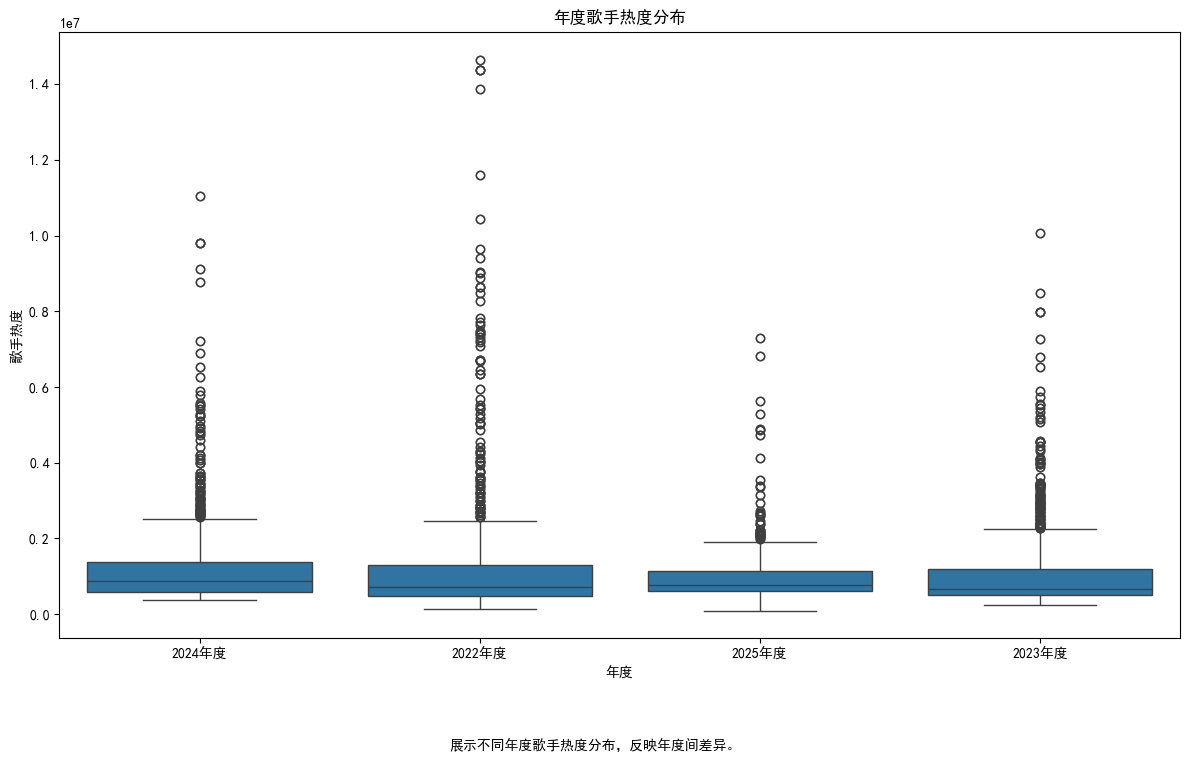

In [15]:
with open("../../data/reporter/year_singer_heat_box.png", "rb") as f:
    img = f.read()
display(Image(data=img))

# 总结与洞察

通过对Bilibili音乐榜单数据的全流程分析，发现榜单呈现出明显的头部效应和流行趋势：
- 头部歌手和专辑长期占据榜单，部分新晋艺人偶有突破，市场竞争激烈。
- 榜单热度与社会热点、平台活动密切相关，年度波动明显。
- 关联规则揭示了部分歌手/专辑的强合作关系，为后续音乐推广和市场决策提供了数据支持。
- 词云和热力图等可视化手段有效揭示了内容热点和用户偏好。

整体来看，Bilibili音乐榜单数据不仅反映了音乐市场的流行风向，也为内容创作、艺人运营和平台策略提供了有力的数据支撑。
